In [4]:
%pip install missingno

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from IPython.display import display

In [7]:
df = pd.read_csv('swiggy.csv')
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [11]:
rows,cols = df.shape
print(f"The dataset has {rows} rows and {cols} columns")

The dataset has 45593 rows and 20 columns


In [13]:
df.describe()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,17.017729,70.231332,17.465186,70.845702,1.023359
std,8.185109,22.883647,7.335122,21.118812,0.839065
min,-30.905562,-88.366217,0.010000,0.010000,0.000000
25%,12.933284,73.170000,12.988453,73.280000,0.000000
50%,18.546947,75.898497,18.633934,76.002574,1.000000
75%,22.728163,78.044095,22.785049,78.107044,2.000000
max,30.914057,88.433452,31.054057,88.563452,3.000000


In [15]:
df.dtypes

ID                                 str
Delivery_person_ID                 str
Delivery_person_Age                str
Delivery_person_Ratings            str
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                         str
Time_Orderd                        str
Time_Order_picked                  str
Weatherconditions                  str
Road_traffic_density               str
Vehicle_condition                int64
Type_of_order                      str
Type_of_vehicle                    str
multiple_deliveries                str
Festival                           str
City                               str
Time_taken(min)                    str
dtype: object

In [21]:
# no missing values
df.isna().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

In [22]:
df.sample(50)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
9410,0x9dec,COIMBRES02DEL02,38,4.9,11.022477,76.995667,11.042477,77.015667,19-03-2022,11:40:00,11:50:00,conditions Fog,High,1,Drinks,motorcycle,1,No,Metropolitian,(min) 35
34930,0x75a,PUNERES13DEL02,NaN,NaN,18.562450,73.916619,18.582450,73.936619,03-04-2022,NaN,11:35:00,conditions Windy,High,0,Snack,motorcycle,0,No,Urban,(min) 32
9009,0x912e,VADRES09DEL01,28,4.7,0.000000,0.000000,0.040000,0.040000,01-04-2022,13:25:00,13:30:00,conditions Stormy,High,1,Snack,motorcycle,0,No,Metropolitian,(min) 19
33190,0xab61,RANCHIRES16DEL03,28,4.6,23.371292,85.327872,23.431292,85.387872,26-03-2022,23:00:00,23:15:00,conditions Cloudy,Low,0,Buffet,motorcycle,1,No,Metropolitian,(min) 23
27704,0x266d,CHENRES07DEL02,38,4.9,13.081878,80.248519,13.101878,80.268519,01-03-2022,09:00:00,09:15:00,conditions Stormy,Low,2,Meal,electric_scooter,1,No,Urban,(min) 27
41371,0x26e5,MUMRES01DEL03,26,4.6,19.126630,72.829976,19.156630,72.859976,05-03-2022,17:50:00,17:55:00,conditions Windy,Medium,1,Snack,motorcycle,1,No,Urban,(min) 26
29168,0xad47,MUMRES17DEL03,39,5,19.121999,72.908493,19.151999,72.938493,19-03-2022,20:50:00,21:00:00,conditions Sunny,Jam,0,Drinks,motorcycle,1,No,Metropolitian,(min) 23
10272,0xb2cf,BANGRES18DEL01,24,4.6,12.913041,77.683237,12.983041,77.753237,02-04-2022,17:15:00,17:25:00,conditions Cloudy,Medium,2,Snack,scooter,2,No,Metropolitian,(min) 38
19303,0x5e4b,CHENRES07DEL01,28,4.1,13.081878,80.248519,13.121878,80.288519,01-04-2022,13:25:00,13:35:00,conditions Fog,High,2,Buffet,motorcycle,0,No,Metropolitian,(min) 32
25911,0xa410,RANCHIRES18DEL03,26,4.6,23.351489,85.324253,23.411489,85.384253,05-04-2022,18:30:00,18:35:00,conditions Sandstorms,Medium,0,Buffet,motorcycle,0,No,Urban,(min) 27


In [25]:
df.loc[43317,"Delivery_person_Ratings"]

'NaN '

In [27]:
(df == 'NaN ').sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64

In [28]:
(df == 'NaN ').sum().sum()

np.int64(8515)

In [32]:
df.replace("NaN ", np.nan).isna().sum().sum()

np.int64(8515)

In [34]:
df.replace("NaN ", np.nan).isna().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64

In [ ]:
# but weather column has still nan values it hasnt changed
(
    df.loc[:,"Weatherconditions"].
    str.replace("conditions ","").
    replace("NaN",np.nan)
)

0             Sunny
1            Stormy
2        Sandstorms
3             Sunny
4            Cloudy
            ...    
45588         Windy
45589         Windy
45590        Cloudy
45591        Cloudy
45592           Fog
Name: Weatherconditions, Length: 45593, dtype: str

In [38]:
df.loc[:,"Weatherconditions"].str.replace("conditions ","").replace("NaN",np.nan).isna().sum()

np.int64(616)

In [39]:
df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,conditions Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,conditions Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 36
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26


In [40]:
# Step 1: Make a copy of the dataframe
missing_df = df.copy()

# Step 2: Replace all "NaN " (with trailing space) across the whole dataset
missing_df = missing_df.replace("NaN ", np.nan)

# Step 3: Remove the word "conditions " from the Weatherconditions column
missing_df['Weatherconditions'] = missing_df['Weatherconditions'].str.replace("conditions ", "")

# Step 4: Turn any leftover "NaN" text into real missing values
missing_df['Weatherconditions'] = missing_df['Weatherconditions'].replace("NaN", np.nan)


In [41]:
missing_df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 36
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26


In [43]:
missing_df.isna().sum().sum()

np.int64(9131)

<Axes: >

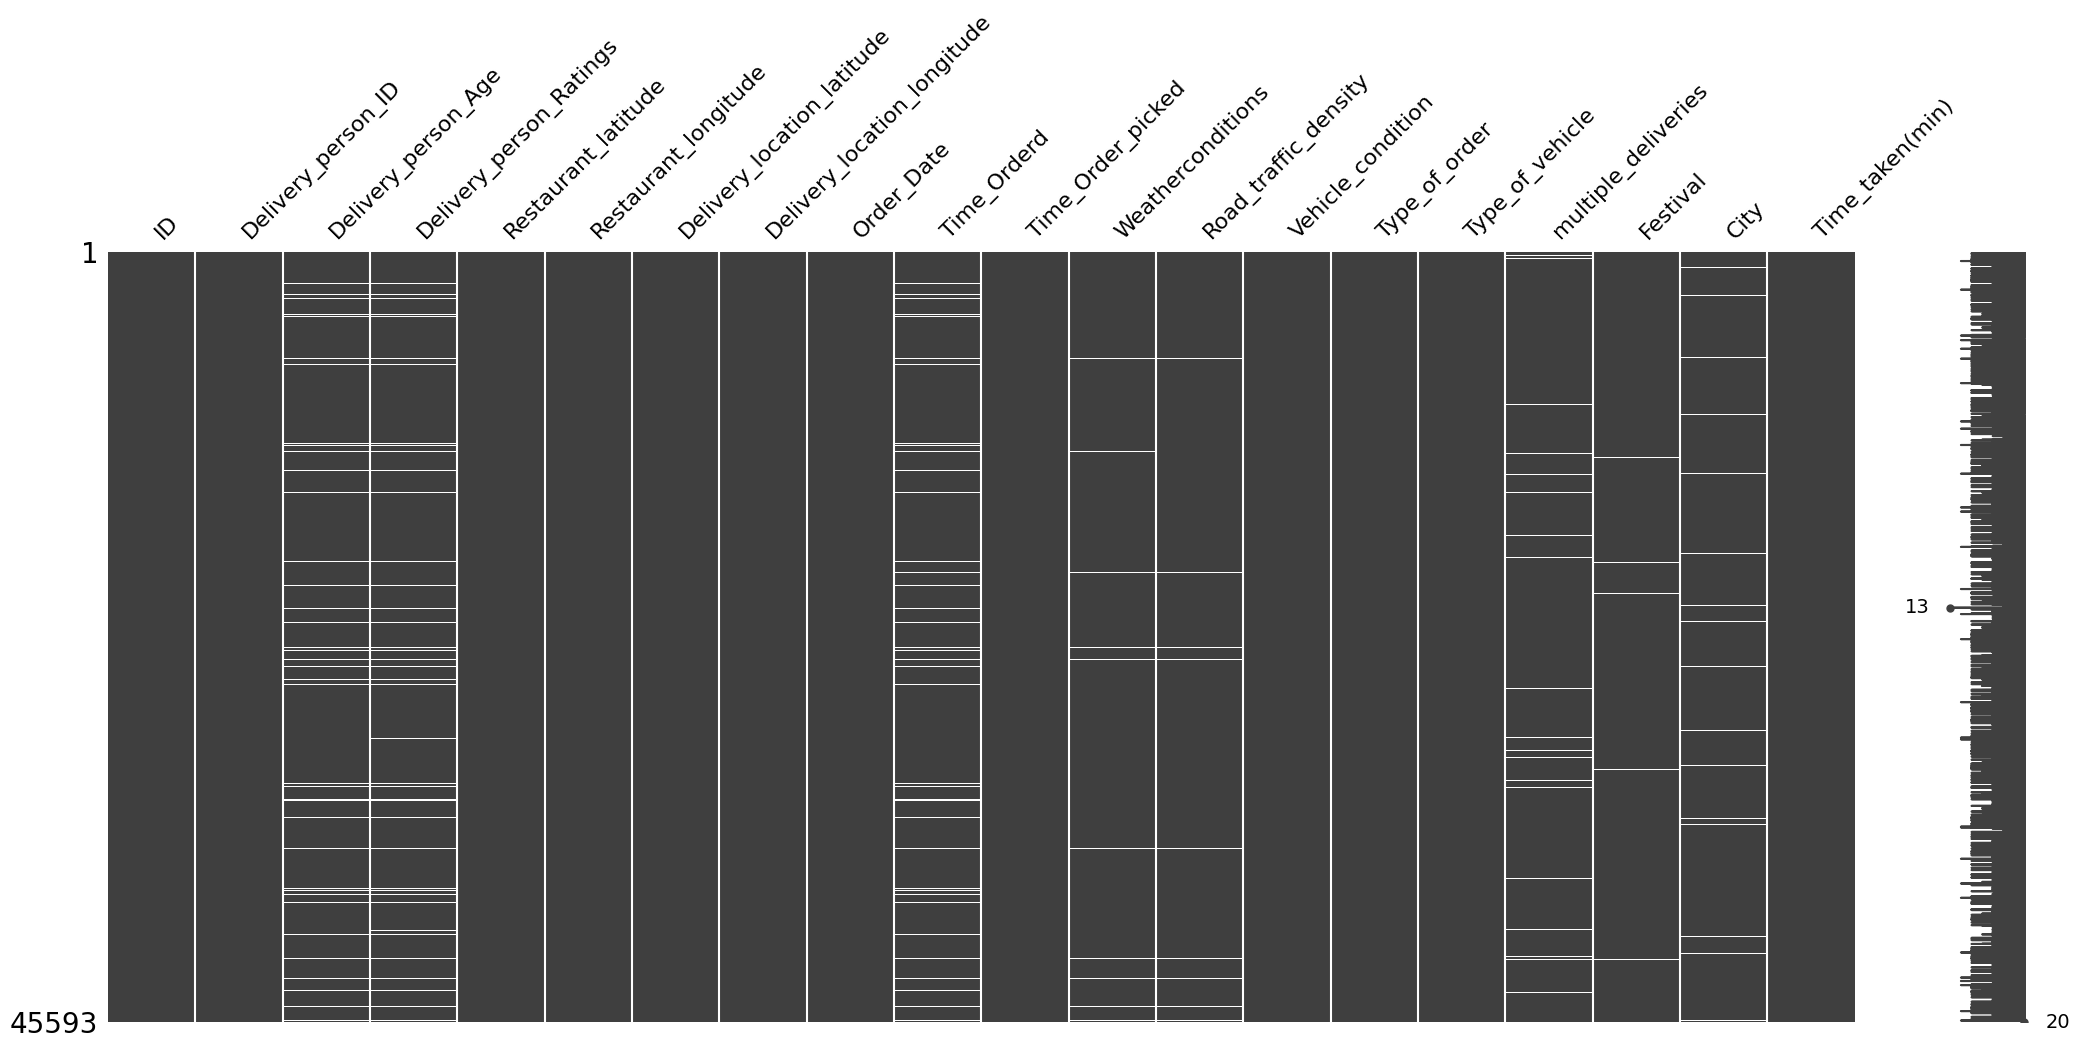

In [45]:
msno.matrix(missing_df)

<Axes: >

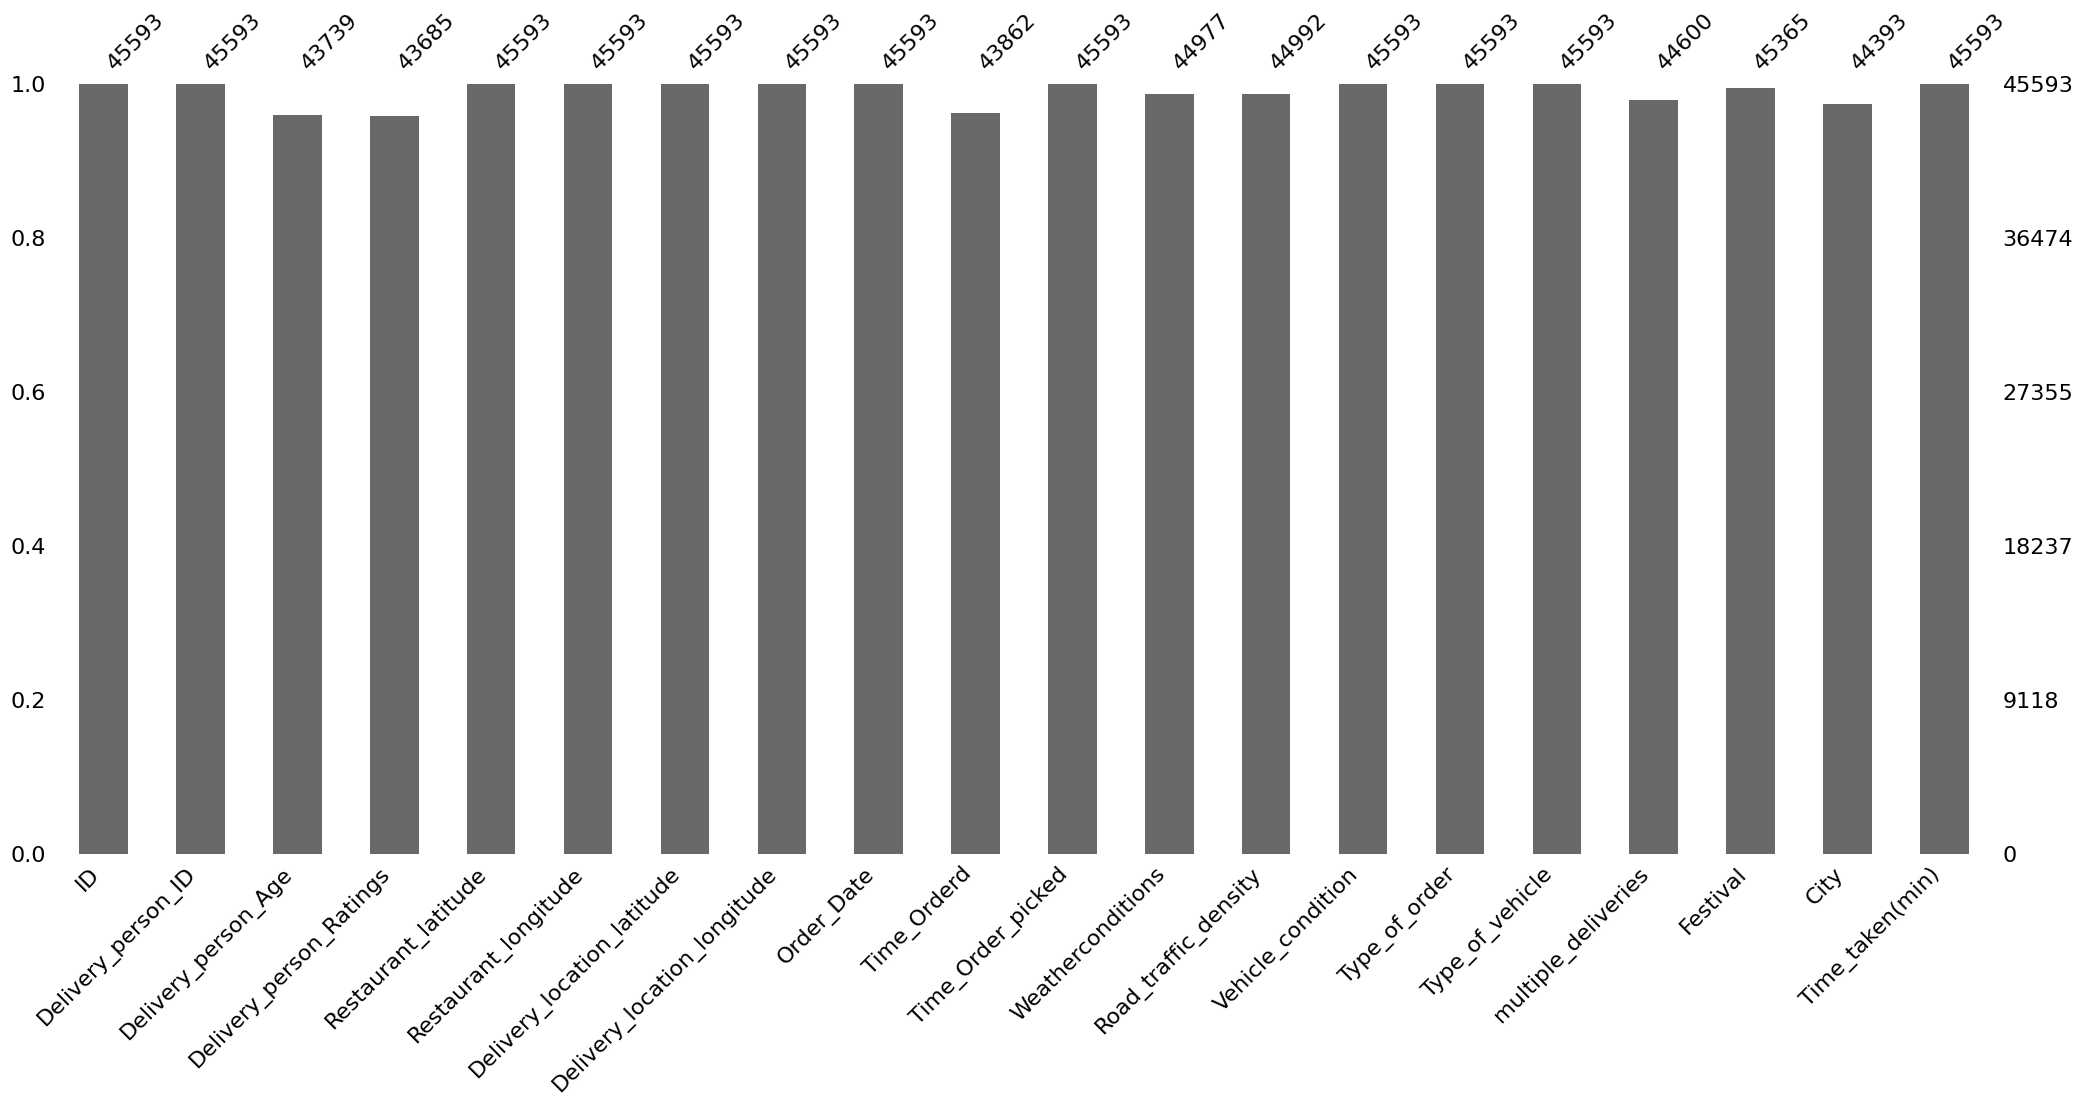

In [46]:
msno.bar(missing_df)

<Axes: >

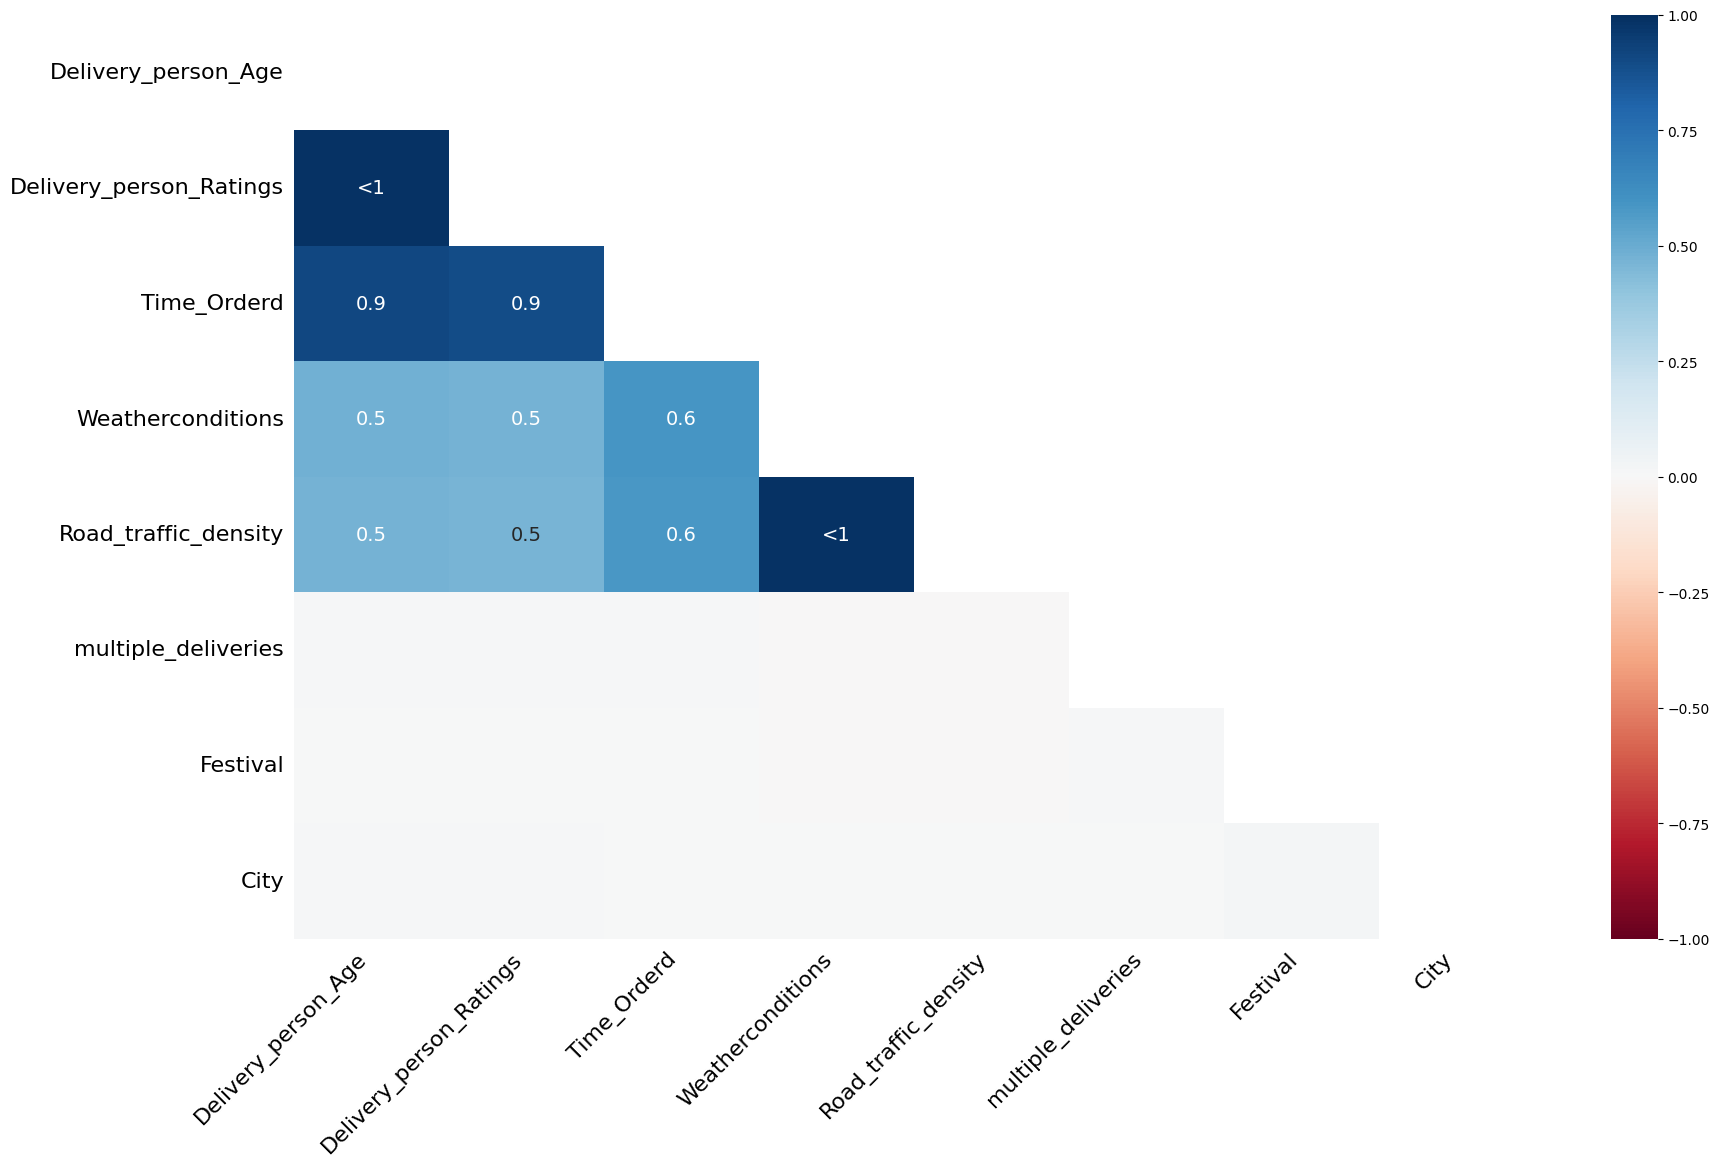

In [47]:
msno.heatmap(missing_df)

Observations

The delivery person columns are correlated to each other. This means that missingness in these columns is highly related which means lack of rider data.
The time ordered column is also related to the rider which shows that the data might be missing due to some network error where the system was unable to log rider details and time of order.

There is a very high correlation between weather patterns and the road traffic information. Be clear that this does not mean that the road traffic and weather columns are correlated. High corr in missingness means that if value in one column is missing, it is a high chance that it will be missing in others as well.

Road traffic density also shows correlation to the rider as it might be provided through the phone of rider (need to investigate).

In [48]:
missing_df[["Weatherconditions","Road_traffic_density"]].isna().sum()

Weatherconditions       616
Road_traffic_density    601
dtype: int64

In [49]:
# prove point of missingness
(
    missing_df[["Weatherconditions","Road_traffic_density"]]
    .isna().all(axis=1)
    .sum()
) /  missing_df[["Weatherconditions","Road_traffic_density"]].isna().sum()

Weatherconditions       0.975649
Road_traffic_density    1.000000
dtype: float64

In [50]:
(missing_df.isna().any(axis=1).sum() / missing_df.shape[0]) * 100

np.float64(9.266773408198627)

In [51]:
def change_col_names(data : pd.DataFrame):
    return (
        data.rename(str.lower,axis=1).rename({
            "delivery_person_id" : "rider_id",
            "delivery_person_age": "age",
            "delivery_person_ratings": "ratings",
            "delivery_location_latitude": "delivery_latitude",
            "delivery_location_longitude": "delivery_longitude",
            "time_orderd": "order_time",
            "time_order_picked": "order_picked_time",
            "weatherconditions": "weather",
            "road_traffic_density": "traffic",
            "city": "city_type",
            "time_taken(min)": "time_taken"},axis=1)
    )

In [52]:
df = change_col_names(df)

In [53]:
df.head()

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


### Why do we drop ID columns before checking duplicates?

| ID (Auto-generated) | Food | Restaurant | Delivery Address | Time |
| :--- | :--- | :--- | :--- | :--- |
| **ORDER_001** | Pizza | Domino's | MG Road, Apt 4 | 7:00 PM |
| **ORDER_002** | Pizza | Domino's | MG Road, Apt 4 | 7:00 PM |

* **Without `.drop()`:** Python sees `ORDER_001` != `ORDER_002` and falsely treats them as different orders.
* **With `.drop()`:** We temporarily hide the random IDs to check if the actual order contents are identical.


In [ ]:
df.drop(columns=["id","rider_id"]).duplicated().sum()
# What happens if you DON'T use .drop()?
# If you run df.duplicated() directly:

# Python looks at the ID column first.
# It sees ORDER_001 in Row 1 and ORDER_002 in Row 2.
# Python says: "Since ORDER_001 does not match ORDER_002, these rows are NOT duplicates!"
# Python gets fooled by the unique ID, even though the actual order details are 100% identical!

np.int64(0)

In [58]:
# unique items in ID column

print(f"The number of unique IDs are {df['id'].nunique()}")

The number of unique IDs are 45593


All the ID values are unique

This column can be dropped from the data

Rider ID





In [59]:
df['rider_id'].nunique()

1320

In [60]:
# rider order count in data

df['rider_id'].value_counts()

rider_id
JAPRES11DEL02        67
PUNERES01DEL01       67
RANCHIRES02DEL01     66
VADRES11DEL02        66
JAPRES03DEL01        66
                     ..
DEHRES18DEL03         7
GOARES01DEL03         7
KOLRES09DEL03         6
KOCRES16DEL03         6
BHPRES010DEL03        5
Name: count, Length: 1320, dtype: int64

In [61]:
# extract city name out of rider id

(
    df['rider_id']
    .str.split("RES")
    .str.get(0)
    .rename("City_Name")
)

0          INDO
1          BANG
2          BANG
3         COIMB
4          CHEN
          ...  
45588       JAP
45589       AGR
45590      CHEN
45591     COIMB
45592    RANCHI
Name: City_Name, Length: 45593, dtype: object

In [66]:
df.dtypes

id                          str
rider_id                    str
age                         str
ratings                     str
restaurant_latitude     float64
restaurant_longitude    float64
delivery_latitude       float64
delivery_longitude      float64
order_date                  str
order_time                  str
order_picked_time           str
weather                     str
traffic                     str
vehicle_condition         int64
type_of_order               str
type_of_vehicle             str
multiple_deliveries         str
festival                    str
city_type                   str
time_taken                  str
dtype: object

## Phase 3 -> according to explanation


# AGE

In [65]:
# datatype

df['age'].dtype

<StringDtype(na_value=nan)>

In [67]:
# min, mean and max values

df['age'].astype(float).describe()

count    43739.000000
mean        29.567137
std          5.815155
min         15.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         50.000000
Name: age, dtype: float64

# Minimum Rider age of 15 is concerning

Investigate further what type of transport is he using?

<Axes: ylabel='age'>

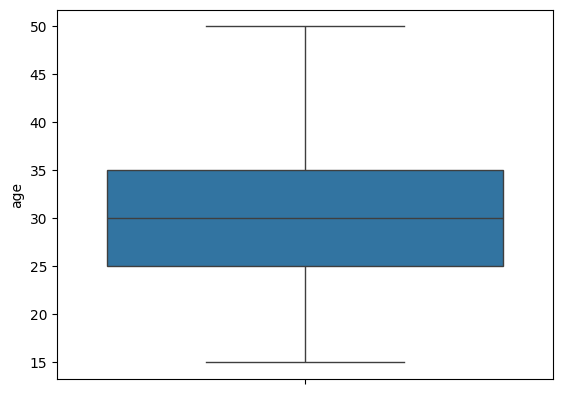

In [68]:
# boxplot of the age column

sns.boxplot(df['age'].astype(float))

In [72]:
# rows of data where rider age is less than 18(minor)

# 1. First ensure 'age' is numeric (safe against any string 'NaN')
df['age'] = pd.to_numeric(df['age'], errors='coerce')
minors_data = df[df['age'] < 18]

minors_data

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken
2387,0x564,JAPRES15DEL03,15.0,1,-26.891191,75.802083,26.981191,75.892083,12-03-2022,NaN,17:20:00,conditions NaN,NaN,3,Meal,motorcycle,0,No,Urban,(min) 15
2905,0xcd0,INDORES010DEL03,15.0,1,22.750040,75.902847,22.810040,75.962847,03-04-2022,NaN,20:30:00,conditions NaN,NaN,3,Snack,scooter,1,No,Metropolitian,(min) 29
2951,0x91a,SURRES17DEL03,15.0,1,21.149569,72.772697,21.209569,72.832697,21-03-2022,NaN,22:10:00,conditions NaN,NaN,3,Buffet,bicycle,1,No,Metropolitian,(min) 20
5902,0x474,CHENRES15DEL03,15.0,1,13.026286,80.275235,13.056286,80.305235,11-03-2022,NaN,20:50:00,conditions NaN,NaN,3,Drinks,bicycle,1,No,Metropolitian,(min) 25
9156,0x73f,BANGRES05DEL01,15.0,1,12.970324,77.645748,13.080324,77.755748,25-03-2022,NaN,23:25:00,conditions NaN,NaN,3,Buffet,motorcycle,2,No,Metropolitian,(min) 34
10900,0x1b49,MUMRES14DEL02,15.0,1,19.181300,72.836191,19.231300,72.886191,30-03-2022,NaN,20:55:00,conditions NaN,NaN,3,Buffet,motorcycle,1,No,Metropolitian,(min) 39
11125,0x40b,SURRES12DEL01,15.0,1,-21.183434,-72.814492,21.193434,72.824492,05-03-2022,NaN,11:30:00,conditions NaN,NaN,3,Meal,scooter,1,No,Urban,(min) 27
12093,0x523,INDORES03DEL02,15.0,1,22.751857,75.866699,22.801857,75.916699,24-03-2022,NaN,21:15:00,conditions NaN,NaN,3,Buffet,bicycle,0,No,Metropolitian,(min) 28
15124,0x18b0,RANCHIRES02DEL01,15.0,1,0.000000,0.000000,0.070000,0.070000,16-03-2022,NaN,23:55:00,conditions NaN,NaN,3,Meal,bicycle,1,No,Metropolitian,(min) 21
15927,0x550,CHENRES08DEL02,15.0,1,13.022394,80.242439,13.072394,80.292439,11-03-2022,NaN,18:10:00,conditions NaN,NaN,3,Snack,bicycle,0,No,Metropolitian,(min) 17


# Observations:

The star ratings of all the riders is 1.

The vehicle condition of these riders is very bad.

No weather and traffic conditions available.

Age of all these riders is 15 which is below the permissable age to drive a vehicle.

Latitude and Longitude values in negative which is not possible. India is situated above the equator so all latitudes should be positive and east of meridian line so longitudes are positive as well.

In [ ]:
# rows of minors

minor_index = minors_data.index.tolist()

38

# Rating

In [75]:
df['ratings'].dtype

<StringDtype(na_value=nan)>

In [76]:
df['ratings'].astype(float).describe()

count    43685.000000
mean         4.633780
std          0.334716
min          1.000000
25%          4.500000
50%          4.700000
75%          4.900000
max          6.000000
Name: ratings, dtype: float64

<Axes: ylabel='ratings'>

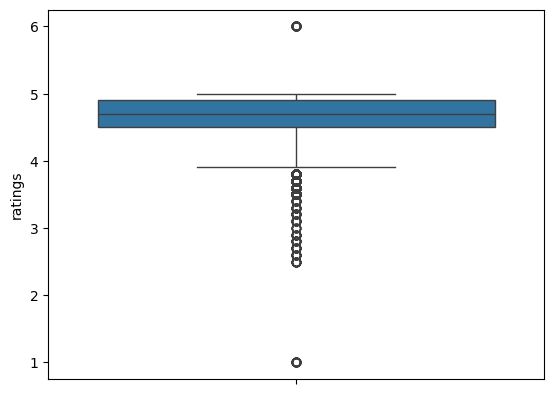

In [77]:
# boxplot
sns.boxplot(df['ratings'].astype(float))

In [81]:
six_star_rating = df[df['ratings'].astype(float) == 6]
six_star_rating

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken
3586,0x46d,BANGRES05DEL01,50.0,6,-12.970324,-77.645748,13.010324,77.685748,13-03-2022,NaN,12:30:00,conditions NaN,NaN,3,Meal,electric_scooter,0,No,Urban,(min) 25
4714,0x493,HYDRES17DEL01,50.0,6,-17.451976,-78.385883,17.561976,78.495883,04-04-2022,NaN,23:20:00,conditions NaN,NaN,3,Snack,bicycle,0,No,Metropolitian,(min) 27
5169,0x4f2,JAPRES08DEL01,50.0,6,-26.910262,-75.783013,27.020262,75.893013,18-03-2022,NaN,18:50:00,conditions NaN,NaN,3,Drinks,scooter,1,No,Metropolitian,(min) 20
5362,0x430,BANGRES19DEL01,50.0,6,12.914264,77.678400,13.024264,77.788400,06-04-2022,NaN,20:55:00,conditions NaN,NaN,3,Meal,electric_scooter,1,No,Metropolitian,(min) 18
5651,0xbef1,AGRRES13DEL02,50.0,6,-27.159795,-78.042990,27.209795,78.092990,13-02-2022,NaN,18:05:00,conditions NaN,NaN,3,Drinks,scooter,1,No,Metropolitian,(min) 20
6394,0x427,JAPRES06DEL02,50.0,6,26.911927,75.797282,27.041927,75.927282,02-04-2022,NaN,22:10:00,conditions NaN,NaN,3,Meal,electric_scooter,0,No,Urban,(min) 20
7031,0x3eb,MYSRES15DEL02,50.0,6,-12.352058,-76.606650,12.372058,76.626650,15-03-2022,NaN,10:00:00,conditions NaN,NaN,3,Buffet,scooter,1,No,Metropolitian,(min) 14
7681,0xd42,VADRES09DEL01,50.0,6,0.000000,0.000000,0.010000,0.010000,21-03-2022,NaN,08:35:00,conditions NaN,NaN,3,Meal,bicycle,1,No,Metropolitian,(min) 22
9499,0x3f0,BANGRES010DEL01,50.0,6,12.933298,77.614293,13.003298,77.684293,12-03-2022,NaN,18:25:00,conditions NaN,NaN,3,Drinks,scooter,1,No,Urban,(min) 17
9535,0x3ef,RANCHIRES13DEL01,50.0,6,-23.374989,-85.335486,23.444989,85.405486,20-03-2022,NaN,17:55:00,conditions NaN,NaN,3,Snack,bicycle,1,No,Metropolitian,(min) 32


In [83]:
# useless data
six_star_index = six_star_rating.index.tolist()
len(six_star_index)

53

# Data removal seems logical at this stage.

# Location Columns

In [84]:
location_columns = df.columns[4:8].tolist()
location_columns

['restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude']

In [97]:
location_subset = df.loc[:,location_columns]
location_subset

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
0,22.745049,75.892471,22.765049,75.912471
1,12.913041,77.683237,13.043041,77.813237
2,12.914264,77.678400,12.924264,77.688400
3,11.003669,76.976494,11.053669,77.026494
4,12.972793,80.249982,13.012793,80.289982
...,...,...,...,...
45588,26.902328,75.794257,26.912328,75.804257
45589,0.000000,0.000000,0.070000,0.070000
45590,13.022394,80.242439,13.052394,80.272439
45591,11.001753,76.986241,11.041753,77.026241


In [98]:
# statistical analysis

location_subset.describe()

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,45593.000000,45593.000000,45593.000000,45593.000000
mean,17.017729,70.231332,17.465186,70.845702
std,8.185109,22.883647,7.335122,21.118812
min,-30.905562,-88.366217,0.010000,0.010000
25%,12.933284,73.170000,12.988453,73.280000
50%,18.546947,75.898497,18.633934,76.002574
75%,22.728163,78.044095,22.785049,78.107044
max,30.914057,88.433452,31.054057,88.563452


# Valid values for lat and long

# India lies to the north of the equator between 6° 44′ and 35° 30′ north latitude
#  and 68° 7′ and 97° 25′ east longitude.

In [94]:
# set the lower bound limits for the lat and long

lower_bound_lat = 6.44
lower_bound_long = 68.70

In [95]:
df.columns

Index(['id', 'rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'order_time', 'order_picked_time', 'weather', 'traffic',
       'vehicle_condition', 'type_of_order', 'type_of_vehicle',
       'multiple_deliveries', 'festival', 'city_type', 'time_taken'],
      dtype='str')

In [96]:
# 1. Define the condition
is_below_bound = (
    (df['restaurant_latitude'] < lower_bound_lat) |
    (df['restaurant_longitude'] < lower_bound_long) |
    (df['delivery_latitude'] < lower_bound_lat) |
    (df['delivery_longitude'] < lower_bound_long)
)

# 2. Filter and sample
df[is_below_bound].sample(50)

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken
29221,0x9457,RANCHIRES02DEL02,37.0,4.6,0.000000,0.000000,0.020000,0.020000,03-04-2022,08:55:00,09:10:00,conditions Cloudy,Low,0,Snack,motorcycle,0,No,Metropolitian,(min) 23
45168,0x516f,RANCHIRES14DEL03,25.0,4.6,0.000000,0.000000,0.090000,0.090000,04-04-2022,21:25:00,21:35:00,conditions Cloudy,Jam,0,Buffet,motorcycle,1,No,Urban,(min) 36
29811,0x6f11,VADRES16DEL02,33.0,3.7,0.000000,0.000000,0.130000,0.130000,18-03-2022,20:45:00,21:00:00,conditions Sandstorms,Jam,2,Meal,electric_scooter,NaN,No,Metropolitian,(min) 41
45428,0xdf09,BHPRES12DEL02,25.0,4.7,0.000000,0.000000,0.020000,0.020000,15-02-2022,10:55:00,11:10:00,conditions Windy,Low,1,Snack,motorcycle,0,No,Urban,(min) 15
19748,0xa508,MYSRES14DEL02,37.0,4.4,0.000000,0.000000,0.020000,0.020000,19-03-2022,09:20:00,09:25:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Metropolitian,(min) 25
17673,0x3bcd,VADRES07DEL02,24.0,4.2,0.000000,0.000000,0.050000,0.050000,26-03-2022,20:20:00,20:25:00,conditions Cloudy,Jam,2,Meal,electric_scooter,1,No,Metropolitian,(min) 32
40539,0x814a,RANCHIRES02DEL02,37.0,4.5,0.000000,0.000000,0.020000,0.020000,17-03-2022,09:40:00,09:55:00,conditions Stormy,Low,2,Snack,electric_scooter,1,No,Metropolitian,(min) 23
1878,0x8ab9,VADRES15DEL01,37.0,4.6,0.000000,0.000000,0.010000,0.010000,30-03-2022,11:25:00,11:40:00,conditions Sunny,High,0,Buffet,motorcycle,1,No,Urban,(min) 28
42353,0xd42a,BHPRES09DEL02,31.0,4.8,0.000000,0.000000,0.020000,0.020000,13-02-2022,11:55:00,12:05:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Metropolitian,(min) 18
8236,0xd9ce,GOARES20DEL01,32.0,5,0.000000,0.000000,0.010000,0.010000,13-02-2022,09:50:00,10:05:00,conditions Cloudy,Low,1,Drinks,scooter,1,No,Metropolitian,(min) 17


In [99]:
# statistical summary of problematic rows where lat long is below the country's geographical limits

location_subset.loc[
    (location_subset['restaurant_latitude'] < lower_bound_lat) |
    (location_subset['restaurant_longitude'] < lower_bound_long) |
    (location_subset['delivery_latitude'] < lower_bound_lat) |
    (location_subset['delivery_longitude'] < lower_bound_long)
].describe()

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,4071.000000,4071.000000,4071.000000,4071.000000
mean,-2.149416,2.068601,2.212538,8.299885
std,6.537913,25.270676,6.538283,23.980011
min,-30.905562,-88.366217,0.010000,0.010000
25%,0.000000,0.000000,0.040000,0.040000
50%,0.000000,0.000000,0.070000,0.070000
75%,0.000000,0.000000,0.110000,0.110000
max,0.000000,88.433452,31.045562,88.523452


(array([1, 2, 3, 4]),
 [Text(1, 0, 'restaurant_latitude'),
  Text(2, 0, 'restaurant_longitude'),
  Text(3, 0, 'delivery_latitude'),
  Text(4, 0, 'delivery_longitude')])

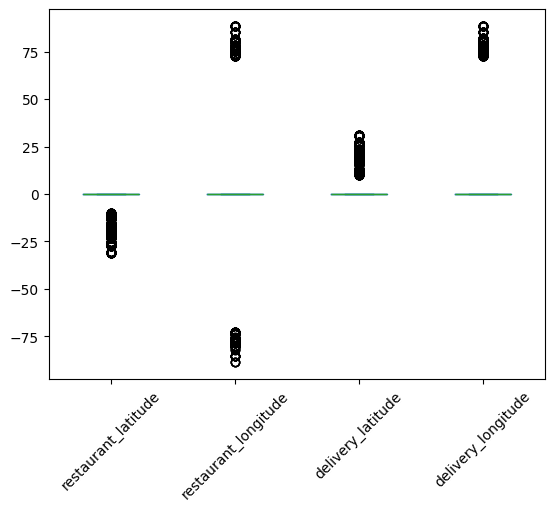

In [100]:
# boxplots for all the anomalies

location_subset.loc[
    (location_subset['restaurant_latitude'] < lower_bound_lat) |
    (location_subset['restaurant_longitude'] < lower_bound_long) |
    (location_subset['delivery_latitude'] < lower_bound_lat) |
    (location_subset['delivery_longitude'] < lower_bound_long)
].plot(kind="box")

plt.xticks(rotation=45)

[Text(1, 0, 'restaurant_latitude'),
 Text(2, 0, 'restaurant_longitude'),
 Text(3, 0, 'delivery_latitude'),
 Text(4, 0, 'delivery_longitude')]

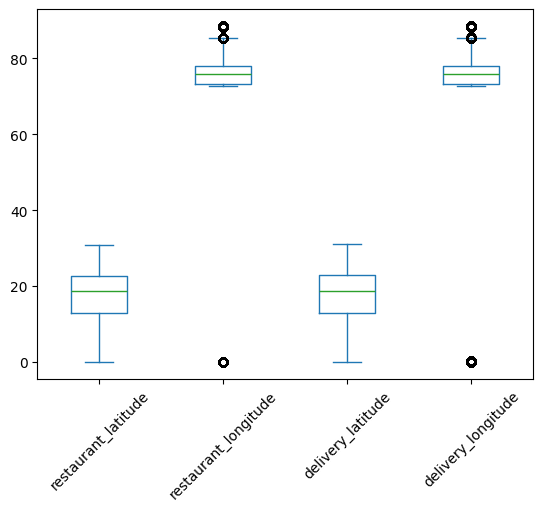

In [101]:
# taking the absolute values

(
    location_subset.abs()
    .plot(kind="box")
)

ax = plt.gca()

ax.set_xticklabels(ax.get_xticklabels(),rotation=45)

In [ ]:
# number of rows after taking absolute values

(
    location_subset.abs()
    .loc[lambda df_:
        (df_['restaurant_latitude'] < lower_bound_lat) |
        (df_['restaurant_longitude'] < lower_bound_long) |
        (df_['delivery_latitude'] < lower_bound_lat) |
        (df_['delivery_longitude'] < lower_bound_long)]
    .shape[0]

)

Number of rows below bounds: 3640


In [104]:
# lat long values less than 1

location_subset.abs().loc[lambda df_:
                        (df_['restaurant_latitude'] < 1) |
                        (df_['restaurant_longitude'] < 1) |
                        (df_['delivery_latitude'] < 1) |
                        (df_['delivery_longitude'] < 1)]

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
33,0.0,0.0,0.11,0.11
52,0.0,0.0,0.03,0.03
57,0.0,0.0,0.08,0.08
59,0.0,0.0,0.06,0.06
67,0.0,0.0,0.02,0.02
...,...,...,...,...
45569,0.0,0.0,0.07,0.07
45576,0.0,0.0,0.13,0.13
45577,0.0,0.0,0.09,0.09
45579,0.0,0.0,0.05,0.05


In [105]:
# bingo exctly 3640 rows have 0 as lat and liong

In [106]:
def clean_lat_long(data: pd.DataFrame, threshold=1):
    data = data.copy()
    
    location_columns = [
        'restaurant_latitude', 'restaurant_longitude',
        'delivery_latitude', 'delivery_longitude'
    ]
    
    for col in location_columns:
        # If the value is less than 1, replace it with NaN
        data.loc[data[col] < threshold, col] = np.nan
        
    return data


In [110]:
clean_lat_long(df).isna().sum()

id                         0
rider_id                   0
age                     1854
ratings                    0
restaurant_latitude     4071
restaurant_longitude    3802
delivery_latitude       3640
delivery_longitude      3640
order_date                 0
order_time                 0
order_picked_time          0
weather                    0
traffic                    0
vehicle_condition          0
type_of_order              0
type_of_vehicle            0
multiple_deliveries        0
festival                   0
city_type                  0
time_taken                 0
dtype: int64

In [111]:
df.columns

Index(['id', 'rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'order_time', 'order_picked_time', 'weather', 'traffic',
       'vehicle_condition', 'type_of_order', 'type_of_vehicle',
       'multiple_deliveries', 'festival', 'city_type', 'time_taken'],
      dtype='str')

# order

In [114]:
df['order_date'].isna().sum()

np.int64(0)

In [ ]:
df['order_date'].unique()
# No cleanign required

<ArrowStringArray>
['19-03-2022', '25-03-2022', '05-04-2022', '26-03-2022', '11-03-2022',
 '04-03-2022', '14-03-2022', '20-03-2022', '12-02-2022', '13-02-2022',
 '14-02-2022', '02-04-2022', '01-03-2022', '16-03-2022', '15-02-2022',
 '10-03-2022', '27-03-2022', '12-03-2022', '01-04-2022', '05-03-2022',
 '11-02-2022', '08-03-2022', '03-04-2022', '30-03-2022', '28-03-2022',
 '18-03-2022', '06-04-2022', '04-04-2022', '24-03-2022', '09-03-2022',
 '02-03-2022', '13-03-2022', '29-03-2022', '31-03-2022', '17-03-2022',
 '07-03-2022', '15-03-2022', '16-02-2022', '03-03-2022', '18-02-2022',
 '23-03-2022', '17-02-2022', '06-03-2022', '21-03-2022']
Length: 44, dtype: str

# date range

order_date = pd.to_datetime(df['order_date'],dayfirst=True)

order_date.max() - order_date.min()

In [119]:
# date range
order_date = pd.to_datetime(df['order_date'],dayfirst=True)
order_date.max() - order_date.min()

Timedelta('54 days 00:00:00')

In [120]:
# min and maximum dates

order_date.agg(["min","max"]).set_axis(["start","end"],axis=0)

start   2022-02-11
end     2022-04-06
Name: order_date, dtype: datetime64[us]

In [121]:
# extract day, day name, month and year

def extract_datetime_features(ser):
    date_col = pd.to_datetime(ser,dayfirst=True)

    return (
        pd.DataFrame(
            {
                "day": date_col.dt.day,
                "month": date_col.dt.month,
                "year": date_col.dt.year,
                "day_of_week": date_col.dt.day_name(),
                "is_weekend": date_col.dt.day_name().isin(["Saturday","Sunday"]).astype(int)
            }
        ))

In [122]:
extract_datetime_features(df['order_date'])

,day,month,year,day_of_week,is_weekend
0,19,3,2022,Saturday,1
1,25,3,2022,Friday,0
2,19,3,2022,Saturday,1
3,5,4,2022,Tuesday,0
4,26,3,2022,Saturday,1
...,...,...,...,...,...
45588,24,3,2022,Thursday,0
45589,16,2,2022,Wednesday,0
45590,11,3,2022,Friday,0
45591,7,3,2022,Monday,0


# Order time and Order picked time

In [ ]:
# extract hour info from data
order_time_hr = pd.to_datetime(df.replace("NaN ",np.nan)['order_time'],format='mixed').dt.hour

order_time_hr

0        11.0
1        19.0
2         8.0
3        18.0
4        13.0
         ... 
45588    11.0
45589    19.0
45590    23.0
45591    13.0
45592    17.0
Name: order_time, Length: 45593, dtype: float64

In [125]:
def time_of_day(ser):
    time_col = pd.to_datetime(ser,format='mixed').dt.hour

    return(
        np.select(condlist=[(ser.between(6,12,inclusive='left')),
                            (ser.between(12,17,inclusive='left')),
                            (ser.between(17,20,inclusive='left')),
                            (ser.between(20,24,inclusive='left'))],
                  choicelist=["morning","afternoon","evening","night"],
                  default="after_midnight")
    )

In [126]:
time_subset = df.loc[:,["order_time","order_picked_time"]]
time_subset

,order_time,order_picked_time
0,11:30:00,11:45:00
1,19:45:00,19:50:00
2,08:30:00,08:45:00
3,18:00:00,18:10:00
4,13:30:00,13:45:00
...,...,...
45588,11:35:00,11:45:00
45589,19:55:00,20:10:00
45590,23:50:00,00:05:00
45591,13:35:00,13:40:00


In [127]:
(
    time_subset
    .dtypes
)

order_time           str
order_picked_time    str
dtype: object

In [128]:
time_subset.columns.tolist()

['order_time', 'order_picked_time']

In [130]:
# calculate the pickup time

(
    time_subset
    .assign(**{
        col: pd.to_datetime(time_subset[col].replace("NaN ",np.nan).dropna(),format="mixed")
        for col in time_subset.columns.tolist()}
    )
    .assign(
        pickup_time = lambda x: (x['order_picked_time'] - x['order_time']).dt.seconds / 60,
        order_time_hour = lambda x: x['order_time'].dt.hour,
        order_time_of_day = lambda x: x['order_time_hour'].pipe(time_of_day)
    )
    .drop(columns=["order_time","order_picked_time"])
)

,pickup_time,order_time_hour,order_time_of_day
0,15.0,11.0,morning
1,5.0,19.0,evening
2,15.0,8.0,morning
3,10.0,18.0,evening
4,15.0,13.0,afternoon
...,...,...,...
45588,10.0,11.0,morning
45589,15.0,19.0,evening
45590,15.0,23.0,night
45591,5.0,13.0,afternoon


# Weather

In [131]:
# value counts

df['weather'].value_counts()

weather
conditions Fog           7654
conditions Stormy        7586
conditions Cloudy        7536
conditions Sandstorms    7495
conditions Windy         7422
conditions Sunny         7284
conditions NaN            616
Name: count, dtype: int64

In [132]:
# unique values
df['weather'].unique()

<ArrowStringArray>
[     'conditions Sunny',     'conditions Stormy', 'conditions Sandstorms',
     'conditions Cloudy',        'conditions Fog',      'conditions Windy',
        'conditions NaN']
Length: 7, dtype: str

In [133]:
# remove conditions from values

(
    df['weather']
    .str.replace("conditions ","")
    .unique()
)

<ArrowStringArray>
['Sunny', 'Stormy', 'Sandstorms', 'Cloudy', 'Fog', 'Windy', 'NaN']
Length: 7, dtype: str

# Traffic

In [134]:
# value counts

df['traffic'].value_counts()

traffic
Low        15477
Jam        14143
Medium     10947
High        4425
NaN          601
Name: count, dtype: int64

In [135]:
# unique values
df['traffic'].unique()

<ArrowStringArray>
['High ', 'Jam ', 'Low ', 'Medium ', 'NaN ']
Length: 5, dtype: str

In [137]:
(
    df['traffic']
    .replace("NaN ",np.nan)
    .str.rstrip()
    .str.lower()
    .unique()
)

<ArrowStringArray>
['high', 'jam', 'low', 'medium', nan]
Length: 5, dtype: str

# Vehicle Condition

In [138]:
# unique values in column

np.sort(df['vehicle_condition'].unique())

array([0, 1, 2, 3])

In [139]:
# value counts

df['type_of_order'].value_counts()

type_of_order
Snack      11533
Meal       11458
Drinks     11322
Buffet     11280
Name: count, dtype: int64

In [140]:
# unique values
df['type_of_order'].unique()

<ArrowStringArray>
['Snack ', 'Drinks ', 'Buffet ', 'Meal ']
Length: 4, dtype: str

In [141]:
(
    df['type_of_order']
    .str.rstrip()
    .str.lower()
    .unique()
)

<ArrowStringArray>
['snack', 'drinks', 'buffet', 'meal']
Length: 4, dtype: str

# Type of vechicle

In [142]:
# value counts

df['type_of_vehicle'].value_counts()

type_of_vehicle
motorcycle           26435
scooter              15276
electric_scooter      3814
bicycle                 68
Name: count, dtype: int64

In [143]:
# unique values
df['type_of_vehicle'].unique()

<ArrowStringArray>
['motorcycle ', 'scooter ', 'electric_scooter ', 'bicycle ']
Length: 4, dtype: str

In [144]:
(
    df['type_of_vehicle']
    .str.rstrip()
    .str.lower()
    .unique()
)

<ArrowStringArray>
['motorcycle', 'scooter', 'electric_scooter', 'bicycle']
Length: 4, dtype: str

# Multiple Deliveries

In [145]:
# datatype of multiple deliveries column

df['multiple_deliveries'].dtype

<StringDtype(na_value=nan)>

In [146]:
# unique values in column

df['multiple_deliveries'].unique()

<ArrowStringArray>
['0', '1', '3', 'NaN ', '2']
Length: 5, dtype: str

In [147]:
# make the column as integer

(
    df['multiple_deliveries']
    .replace("NaN ",np.nan)
    .astype(float)
    .unique()
)

array([ 0.,  1.,  3., nan,  2.])

# Festival

In [148]:
# unique values in column

df['festival'].unique()

<ArrowStringArray>
['No ', 'Yes ', 'NaN ']
Length: 3, dtype: str

In [150]:
(
    df['festival']
    .replace("NaN ",np.nan)
    .str.rstrip()
    .str.lower()
    .unique()
)

<ArrowStringArray>
['no', 'yes', nan]
Length: 3, dtype: str

# City type

In [151]:
# unique values in city type

df['city_type'].unique()

<ArrowStringArray>
['Urban ', 'Metropolitian ', 'Semi-Urban ', 'NaN ']
Length: 4, dtype: str

In [153]:
(
    df['city_type']
    .replace("NaN ",np.nan)
    .str.rstrip()
    .str.lower()
    .unique()
)

<ArrowStringArray>
['urban', 'metropolitian', 'semi-urban', nan]
Length: 4, dtype: str

# Time taken

In [154]:
# datatype of time taken

df['time_taken'].dtype

<StringDtype(na_value=nan)>

In [155]:
(
    df['time_taken']
    .str.replace("(min) ","")
    .astype(int)
)

0        24
1        33
2        26
3        21
4        30
         ..
45588    32
45589    36
45590    16
45591    26
45592    36
Name: time_taken, Length: 45593, dtype: int64

# Perform cleaning and feature building

In [156]:
df.columns

Index(['id', 'rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'order_time', 'order_picked_time', 'weather', 'traffic',
       'vehicle_condition', 'type_of_order', 'type_of_vehicle',
       'multiple_deliveries', 'festival', 'city_type', 'time_taken'],
      dtype='str')

In [157]:
# 1. Helper function for time of day
def time_of_day(hour_series):
    """Maps hour (0-23) to morning, afternoon, evening, night."""
    return np.select(
        condlist=[
            hour_series.between(6, 12, inclusive='left'),
            hour_series.between(12, 17, inclusive='left'),
            hour_series.between(17, 20, inclusive='left'),
            hour_series.between(20, 24, inclusive='left')
        ],
        choicelist=["morning", "afternoon", "evening", "night"],
        default="after_midnight"
    )


# 2. Master Data Cleaning Function
def data_cleaning(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()

    # Step 1: Drop useless 'id' column and corrupt rows (minors & 6-star ratings)
    minor_index = data[pd.to_numeric(data["age"], errors="coerce") < 18].index.tolist()
    six_star_index = data[pd.to_numeric(data["ratings"], errors="coerce") == 6].index.tolist()

    data = data.drop(columns="id", errors="ignore")
    data = data.drop(index=minor_index, errors="ignore")
    data = data.drop(index=six_star_index, errors="ignore")
    data = data.replace("NaN ", np.nan)

    # Step 2: Extract city_name from rider_id
    data["city_name"] = data["rider_id"].str.split("RES").str.get(0)

    # Step 3: Convert numeric columns
    data["age"] = data["age"].astype(float)
    data["ratings"] = data["ratings"].astype(float)
    data["multiple_deliveries"] = data["multiple_deliveries"].astype(float)

    # Step 4: Fix location coordinates (make positive)
    location_cols = [
        "restaurant_latitude", "restaurant_longitude",
        "delivery_latitude", "delivery_longitude"
    ]
    for col in location_cols:
        data[col] = data[col].abs()

    # Step 5: Extract date features from order_date
    order_date = pd.to_datetime(data["order_date"], dayfirst=True)
    data["order_day"] = order_date.dt.day
    data["order_month"] = order_date.dt.month
    data["order_day_of_week"] = order_date.dt.day_name().str.lower()
    data["is_weekend"] = (order_date.dt.dayofweek >= 5).astype(int)

    # Step 6: Extract time features and calculate pickup duration (in minutes)
    order_time = pd.to_datetime(data["order_time"], format="mixed")
    order_picked_time = pd.to_datetime(data["order_picked_time"], format="mixed")

    data["pickup_time_minutes"] = (order_picked_time - order_time).dt.seconds / 60
    data["order_time_hour"] = order_time.dt.hour
    data["order_time_of_day"] = time_of_day(data["order_time_hour"])

    # Drop raw order time columns after extracting features
    data = data.drop(columns=["order_time", "order_picked_time"])

    # Step 7: Clean categorical columns (strip spaces & convert to lowercase)
    data["weather"] = (
        data["weather"]
        .str.replace("conditions ", "")
        .str.lower()
        .replace("nan", np.nan)
    )

    categorical_cols = ["traffic", "type_of_order", "type_of_vehicle", "festival", "city_type"]
    for col in categorical_cols:
        data[col] = data[col].str.rstrip().str.lower()

    # Step 8: Clean target column (time_taken: "(min) 24" -> 24)
    data["time_taken"] = data["time_taken"].str.replace("(min) ", "").astype(int)

    return data


In [158]:
# Apply the clean function
cleaned_df = data_cleaning(df)

# Check the results
print("Cleaned DataFrame shape:", cleaned_df.shape)
cleaned_df.head()


Cleaned DataFrame shape: (45502, 25)


,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,city_type,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,sunny,high,...,urban,24,INDO,19,3,saturday,1,15.0,11.0,morning
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,stormy,jam,...,metropolitian,33,BANG,25,3,friday,0,5.0,19.0,evening
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,sandstorms,low,...,urban,26,BANG,19,3,saturday,1,15.0,8.0,morning
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,sunny,medium,...,metropolitian,21,COIMB,5,4,tuesday,0,10.0,18.0,evening
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,cloudy,high,...,metropolitian,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon


In [159]:
location_subset.columns.tolist()

['restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude']

# 2. Why "Haversine" Formula specifically?
Because the Earth is a round sphere, not a flat sheet of paper:

You cannot just use simple school geometry sqrt((x2-x1)^2 + (y2-y1)^2).
The Haversine formula accounts for the Earth's curvature (using Earth's radius = 6,371 km) to calculate the exact real-world distance in kilometers between two GPS points.

In [160]:
def calculate_haversine_distance(df):
    location_columns = location_subset.columns.tolist()
    lat1 = df[location_columns[0]]
    lon1 = df[location_columns[1]]
    lat2 = df[location_columns[2]]
    lon2 = df[location_columns[3]]

    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(
        dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2

    c = 2 * np.arcsin(np.sqrt(a))
    distance = 6371 * c

    return (
        df.assign(
            distance = distance)
    )

In [161]:
# 1. Main data cleaning
cleaned_data = data_cleaning(df)

# 2. Mark coordinates < 1 as NaN
cleaned_data = clean_lat_long(cleaned_data)

# 3. Calculate distance in km
cleaned_data = calculate_haversine_distance(cleaned_data)

# View final cleaned data
cleaned_data.head()


,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,sunny,high,...,24,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,stormy,jam,...,33,BANG,25,3,friday,0,5.0,19.0,evening,20.183530
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,sandstorms,low,...,26,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,sunny,medium,...,21,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,cloudy,high,...,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138


,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,41872.000000,41872.000000,41872.000000,41872.000000
mean,18.913696,76.921664,18.977356,76.985325
std,5.467265,3.503107,5.469056,3.503260
min,9.957144,72.768726,9.967144,72.778726
25%,12.986047,73.897902,13.065996,73.940327
50%,19.065838,76.618203,19.124049,76.662620
75%,22.751234,78.368855,22.820040,78.405467
max,30.914057,88.433452,31.054057,88.563452


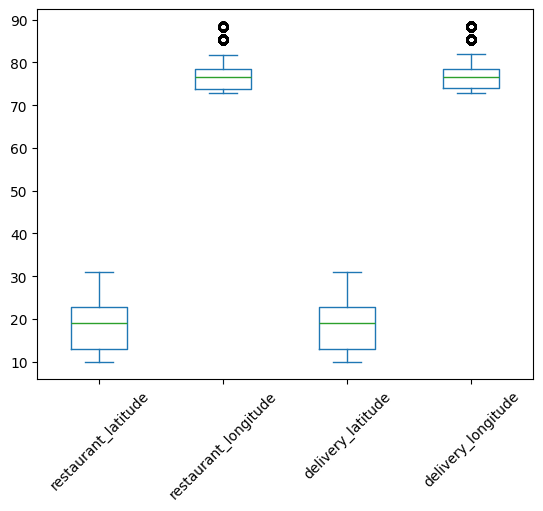

In [164]:
# location columns

cleaned_data[location_columns].plot(kind="box")

plt.xticks(rotation=45)

display(cleaned_data[location_columns].describe())

# Save cleaned data

In [165]:
# save the cleaned data

cleaned_data.to_csv("cleaned_data.csv",index=False)

In [166]:
# load the cleaned data

cleaned_data_load = pd.read_csv("cleaned_data.csv")

In [167]:
# data types of cleaned data

cleaned_data_load.dtypes

rider_id                    str
age                     float64
ratings                 float64
restaurant_latitude     float64
restaurant_longitude    float64
delivery_latitude       float64
delivery_longitude      float64
order_date                  str
weather                     str
traffic                     str
vehicle_condition         int64
type_of_order               str
type_of_vehicle             str
multiple_deliveries     float64
festival                    str
city_type                   str
time_taken                int64
city_name                   str
order_day                 int64
order_month               int64
order_day_of_week           str
is_weekend                int64
pickup_time_minutes     float64
order_time_hour         float64
order_time_of_day           str
distance                float64
dtype: object

In [168]:
cleaned_data_load

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,sunny,high,...,24,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,stormy,jam,...,33,BANG,25,3,friday,0,5.0,19.0,evening,20.183530
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,sandstorms,low,...,26,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,sunny,medium,...,21,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,cloudy,high,...,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,windy,high,...,32,JAP,24,3,thursday,0,10.0,11.0,morning,1.489846
45498,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,NaN,16-02-2022,windy,jam,...,36,AGR,16,2,wednesday,0,15.0,19.0,evening,NaN
45499,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,cloudy,low,...,16,CHEN,11,3,friday,0,15.0,23.0,night,4.657195
45500,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,cloudy,high,...,26,COIMB,7,3,monday,0,5.0,13.0,afternoon,6.232393
